In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
np.set_printoptions(suppress=True)

import json

with open('../config.json', 'r') as f:
    config = json.load(f)

ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = [el for el in ELEMENTS_TO_KEEP if el != 'Fe']

PREDICTION_PATH_DICT = config["prediction_path"]
PREPROCESSED_DATA_PATH_DICT = config["preprocessed_data_path"]
FIGURES_PATH = config["figures_path"]['all']


DATASETS = ['Konstytucja', 'corroded', 'Merkuriusz', 'Kopernik']

CMAP = plt.get_cmap('tab20')

In [2]:
df, y_true = join_datasets_into_one(
                            DATASETS, 
                            PREDICTION_PATH_DICT,
                            PREPROCESSED_DATA_PATH_DICT,
                            ELEMENTS_TO_KEEP_NO_FE
                            )

X = np.array(df.values)

In [3]:
from sklearn.decomposition import PCA

n_components = 3
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [4]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.components_

array([[ 0.19531186,  0.26492621,  0.19875945,  0.40169799,  0.38374298,
         0.33687975,  0.50308662,  0.01183837,  0.29077052,  0.17301992,
         0.24966871],
       [ 0.28624936,  0.27398517,  0.63892199, -0.18669416, -0.10533091,
        -0.26077077, -0.39440396,  0.15696823,  0.18320327,  0.27850498,
         0.17175404],
       [ 0.05642345, -0.35263417,  0.16485778, -0.03448636, -0.00261012,
         0.56754878, -0.1612424 ,  0.68177475, -0.00039904, -0.10837969,
        -0.13934659]])

In [5]:
pca.components_[0,:] #PC1

array([0.19531186, 0.26492621, 0.19875945, 0.40169799, 0.38374298,
       0.33687975, 0.50308662, 0.01183837, 0.29077052, 0.17301992,
       0.24966871])

In [6]:
pca.components_[1,:] #PC2

array([ 0.28624936,  0.27398517,  0.63892199, -0.18669416, -0.10533091,
       -0.26077077, -0.39440396,  0.15696823,  0.18320327,  0.27850498,
        0.17175404])

In [7]:
pca.components_[2,:] #PC3

array([ 0.05642345, -0.35263417,  0.16485778, -0.03448636, -0.00261012,
        0.56754878, -0.1612424 ,  0.68177475, -0.00039904, -0.10837969,
       -0.13934659])

In [8]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.explained_variance_ratio_

array([0.48440794, 0.2589439 , 0.09714453])

In [9]:
# elements corresponding to consecutive dimensions
print(ELEMENTS_TO_KEEP_NO_FE)

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Mg', 'Na', 'K']


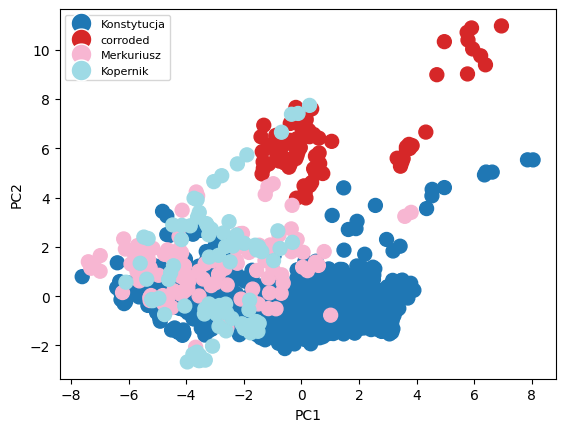

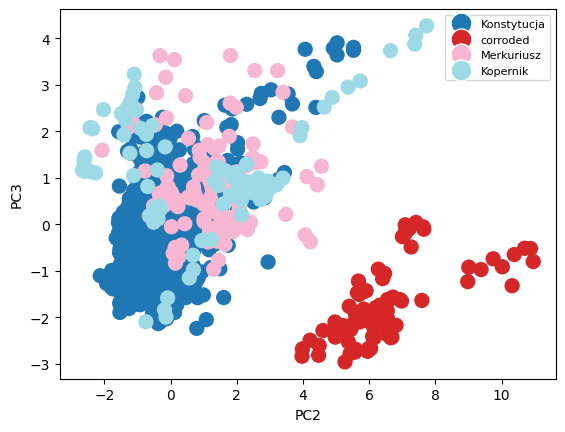

In [10]:
visualise_pca(X_pca, y_true, dimensions=[0,1], whether_sort=False, figures_path=None)

visualise_pca(X_pca, y_true, dimensions=[1, 2], whether_sort=False, figures_path=None)

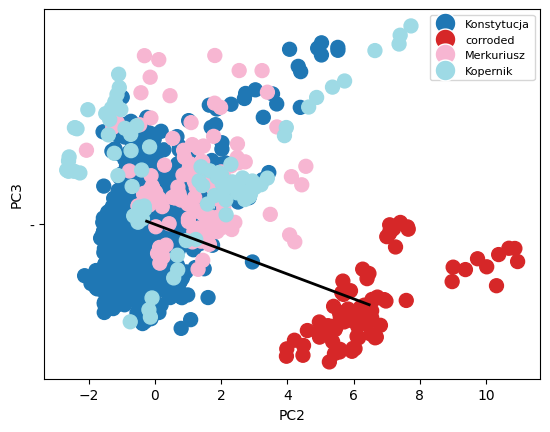

In [11]:
# let's choose some interesting dimensions and project data onto it
dimensions=[1,2]

pc1 = X_pca[:, dimensions[0]]
pc2 = X_pca[:, dimensions[1]]
X_2d = np.column_stack((pc1, pc2))

# let's find means of class 'not corroded' and 'corroded' (on PC plane, 2D)
class0 = X_2d[y_true != 'corroded']
class1 = X_2d[y_true == 'corroded']

mu0 = class0.mean(axis=0)
mu1 = class1.mean(axis=0)

# let's draw a vector from mu0 to m1 just using simple formula t*mu0 + (1-t)*mu1 (all points in between)
t = np.linspace(0, 1, 100)
x_interval = mu0[0]*t + (1-t) * mu1[0]
y_interval = mu0[1]*t + (1-t) * mu1[1]

plt.plot(x_interval, y_interval, 'black', '-', linewidth=2);

visualise_pca(X_pca, y_true, dimensions=[1, 2], whether_sort=False, figures_path=None)

In [12]:
#vector from not corroded to corroded (on PC plane, 2D)
w = mu1 - mu0
w = w.reshape(1,-1) #to get horizontal vector

# the entries of vector w are the coefficients in the PC basis
# so the actual vector w in standard basis is different
# it is a sum of two vectors: first PC rescaled by w[0] plus second PC rescaled by w[1]
# so to get the equivalent of w in high dimensional space we need matrix multiplication
vector_in_9d = w @ pca.components_[dimensions, :]
vector_in_9d
# now the consecutive entries of this vector correspond to consecutive elements from ELEMENTS_TO_KEEP_NO_FE list
# those elements that correspond to positive entries pull the point towards corroded group
# (are consistent with the direction of vector mu1-mu0, i.e. from mu0 to mu1
# those that correspond to negative entries pull toward not corroded group

array([[ 1.82356678,  2.47470181,  4.00049135, -1.19349403, -0.70356972,
        -2.77127335, -2.36282279, -0.16722568,  1.23258422,  2.06704959,
         1.4047863 ]])

In [13]:
ELEMENTS_TO_KEEP_NO_FE

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Mg', 'Na', 'K']

In [14]:
# sanity check: project it back to 2D PC plane
# we should get exactly mu1-mu0
V = pca.components_[dimensions]
res = V @ vector_in_9d.T
print(res)
print('-------------')
print(mu1-mu0)
print('-------------')
# ok

[[ 6.72405371]
 [-1.79339072]]
-------------
[ 6.72405371 -1.79339072]
-------------


In [26]:
# ATTENTION
# pca.transform will not work
pca.transform(vector_in_9d)[:, dimensions]
# it is not equal to mu1-mu0, because transform also does shifting (centering)

array([[15.58737319, -1.50645027]])